# Build Your First Neural Network

## Help a flower sorter make an informed guess

Imagine a tray of iris flowers whose name tags have fallen off. We can measure each flower, but we would like a small program to suggest which species it belongs to.

Our program will receive four measurements and choose among three names: **setosa**, **versicolor**, and **virginica**. This is a **classification** task: the answer is a category, rather than an amount such as temperature.

We will build a small neural network, teach it from labeled examples, compare it with a simpler model, and preserve everything needed to make another prediction later.

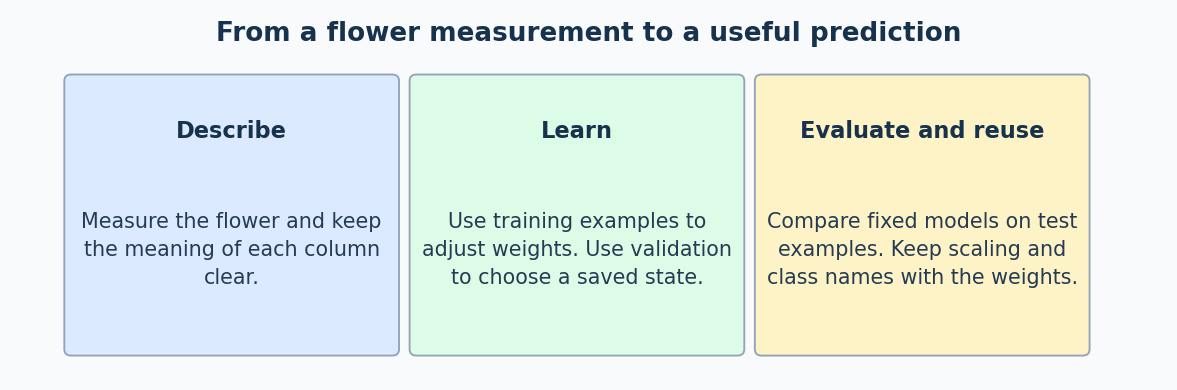

The [code companion](12_Build_Your_First_Neural_Network.ipynb) performs the complete project on CPU. The dataset comes bundled with scikit-learn, so no separate data download or credentials are needed after installing the [README dependencies](README.md).

This is a small learning project, not a tool for identifying any flower we might encounter. The model only knows the three categories represented in its data.

## Start with the problem this lesson solves

We want to identify an Iris flower's species from four measured lengths and widths. The inputs are measurements; the target is one of three species. The ANN learns combinations of measurements that help distinguish classes, then converts those combinations into three competing scores.

A useful project includes more than the network: feature order, training-only preprocessing, a baseline, separate evaluation data, and a way to reuse the same prediction recipe. Each part prevents a different way of obtaining a misleading or unusable result.

## Follow one miniature flower classifier completely

To make every multiplication visible, use a **hand-chosen 4 → 2 → 3 miniature**, smaller than the companion's trained 4 → 8 → 3 model. Its numbers are teaching values, not fitted Iris statistics or predictions.

**Scale the measurements.** In the order sepal length, sepal width, petal length, petal width, take raw measurements $[6,3,3,2]$, illustrative training means $[5,3,4,1]$, and scales $[1,0.5,1,0.5]$. Subtract the corresponding mean and divide by the corresponding scale:

$$x=[(6-5)/1,(3-3)/0.5,(3-4)/1,(2-1)/0.5]=[1,0,-1,2].$$

A value of two in the last position means two training standard deviations above its mean, not two centimeters. Fitting this transformation on test flowers would let evaluation data influence the recipe.

**Compute both hidden neurons.** Choose weight rows $[1,0,-1,0]$ and $[0,1,0,-1]$, with biases zero and one:

$$z_1=1(1)+0(0)+(-1)(-1)+2(0)+0=2,$$
$$z_2=1(0)+0(1)+(-1)(0)+2(-1)+1=-1.$$

Apply ReLU to obtain $h=[2,0]$.

**Compute all class scores.** Choose output weight rows $[1,0]$, $[0,1]$, and $[-1,1]$, with all output biases zero. The three logits are $[2(1)+0(0),2(0)+0(1),2(-1)+0(1)]=[2,0,-2]$.

**Turn scores into probabilities.** For stable softmax, subtract the maximum two first: $[0,-2,-4]$. Exponentials are approximately $[1,0.135335,0.018316]$, with sum $1.153651$. Divide to obtain $[0.866813,0.117310,0.015876]$. The probabilities sum to one, and the largest picks class zero. Class names must come from the stored label mapping.

**Use the known label to teach.** If this example's true class is one, the prediction is wrong and loss is $-\ln(0.117310)\approx2.142932$. Logit gradients are probability minus one-hot target: $[0.866813,-0.882690,0.015876]$. They encourage lower wrong-class scores and a higher true-class score.

For a simple bias-only illustration, freeze all weights and adjust only class one's output bias with rate $0.1$. Its bias changes from zero to $0-0.1(-0.882690)=0.088269$, so the logits become $[2,0.088269,-2]$. Class one's probability increases to about $0.1268$ and loss drops to about $2.0654$. Actual ANN training updates all trainable layers; this restricted step isolates how a classification error guides one parameter.

## Why the complete project can help with new flowers

The hidden layer creates learned combinations of measurements; the output layer uses them as evidence for species. Training makes the parameters useful, while held-out evaluation checks whether that usefulness extends beyond the training flowers. A logistic-regression baseline tests whether the nonlinear network adds value on this small dataset.

Inference repeats feature ordering, stored scaling, forward computation, and class mapping. It does not refit the scaler, access a target label, or update the model. Saving only the weights loses part of the meaning of the input and output numbers, so the companion saves the prediction recipe too. Similar test accuracy between ANN and baseline is a valid result, not a reason to hide the baseline.

## Give every measurement a clear meaning

The [bundled Iris dataset](https://scikit-learn.org/1.6/modules/generated/sklearn.datasets.load_iris.html) contains a hundred and fifty examples, with fifty examples from each of three species. Each example has four measurements in centimeters.

A **petal** is part of the flower's showy inner structure. **Sepals** are the outer flower parts that enclose the bud. Their lengths and widths provide different clues about the flower.

| Feature, in the order the program expects | What it measures | First dataset row |
| --- | --- | --- |
| Sepal length | Length of a sepal | 5.1 cm |
| Sepal width | Width of a sepal | 3.5 cm |
| Petal length | Length of a petal | 1.4 cm |
| Petal width | Width of a petal | 0.2 cm |

A **feature** is an input measurement. A **target** is the known answer attached to a training example. This row's target is setosa.

Inside the program, species names become integer indices: zero for setosa, one for versicolor, and two for virginica. The indices are positions in a list, not a ranking. Virginica is not “twice as much flower” as versicolor.

Our measurement table has shape `(150, 4)`: one row per flower and one column per feature. The target array has shape `(150,)`, one class index per row. Keeping the rows paired is essential; a perfectly working program cannot learn the intended relationship from mismatched measurements and labels.

## Separate learning from judging the result

Before fitting a model or learning a scaling rule, split the examples into three nonoverlapping groups.

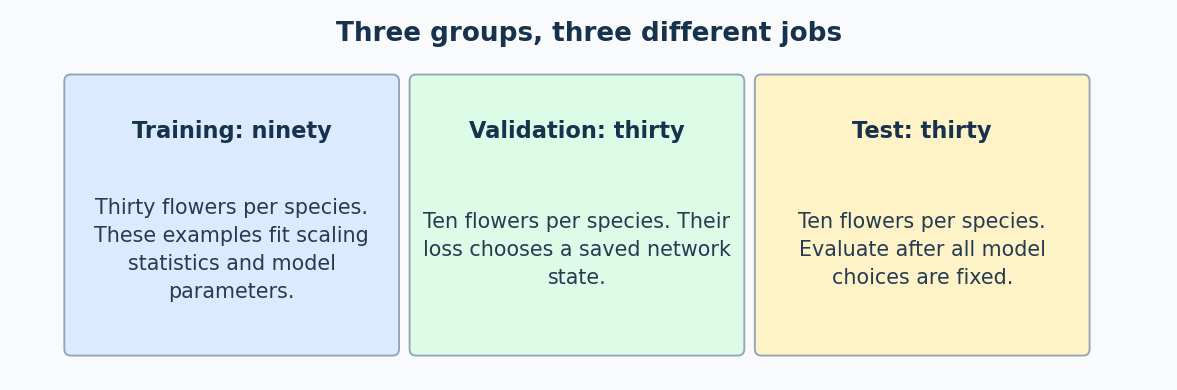

| Group | What we use it for | What it must not do |
| --- | --- | --- |
| Training | Fit scaling statistics and change model parameters | Stand in for evidence about unfamiliar examples |
| Validation | Select the network's saved parameter state | Supply gradient updates |
| Test | Compare the fixed models at the end | Guide further tuning in this project |

The split is **stratified**, meaning it preserves each species' proportion. We obtain thirty flowers of each species for training and ten of each for each remaining group. The code splits row indices so a flower's measurements stay attached to its label.

Fixed random seeds make the starting choices repeatable in the stated environment. They do not make one small split a definitive assessment. Another reasonable split may produce different results.

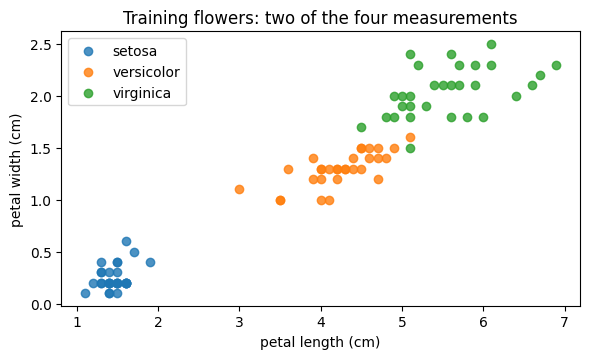

Only training flowers appear in this picture. It shows two dimensions so we can read it easily; both models receive all four measurements. Nearby dots of different species warn us that an exact rule based on a single visible measurement may not be enough.

## Put the measurements on comparable scales

Some columns naturally contain larger numbers than others. That can make optimization harder because the same weight change interacts with different input magnitudes.

We **standardize** each feature: subtract its training mean, then divide by its training standard deviation. The mean is the average, and the standard deviation measures spread around that average.

$$x_{\mathrm{scaled}}=\frac{x-\mu}{s}.$$

$x$ is a raw measurement, $\mu$ is the training-column mean, and $s$ is its training-column standard deviation. These statistics are separate for every feature.

For a small invented example, suppose a feature's training mean is five centimeters and its spread is half a centimeter:

| Raw measurement | Calculation | Scaled value | Meaning |
| --- | --- | --- | --- |
| 4.5 | $(4.5-5)/0.5$ | -1 | One training spread below the center |
| 5 | $(5-5)/0.5$ | 0 | At the training center |
| 6 | $(6-5)/0.5$ | 2 | Two training spreads above the center |

These are illustrative statistics; the companion prints the actual values it learns from its training split. Scaling does not remove the feature or change which flower owns the row. It changes its numerical representation.

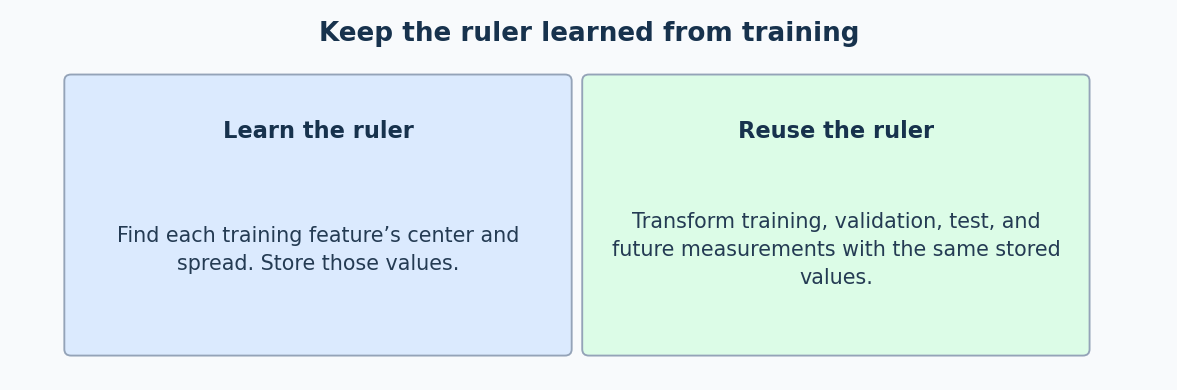

Never recalculate a new ruler separately for each new flower. We store the training statistics and reuse them for validation, test, and future predictions. Learning them from all examples before splitting would let held-out information influence preparation. The code also checks that no feature has zero spread before dividing.

## Build a network small enough to understand

A neural network is a collection of adjustable calculations. Here the architecture is deliberately small: four inputs, eight hidden units, and three output scores.

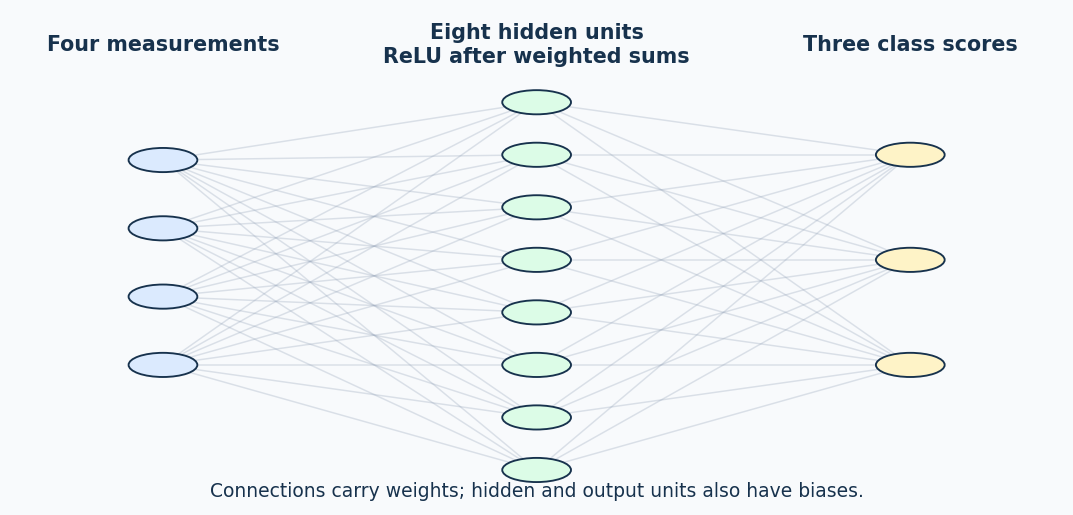

A **weight** multiplies an incoming value, controlling its contribution. A **bias** adds an offset. A **hidden unit** combines its inputs and then applies an activation function; its value is intermediate rather than a named species prediction.

Our activation is **ReLU**. It keeps positive values and replaces negative values with zero. This bend lets the overall model form relationships that a single linear calculation cannot represent.

| PyTorch layer | Input per flower | Output per flower | Its purpose |
| --- | --- | --- | --- |
| `Linear(4, 8)` | Four scaled measurements | Eight weighted sums plus biases | Form learned combinations of the measurements |
| `ReLU()` | Eight scores | Eight activated values | Add a nonlinear bend |
| `Linear(8, 3)` | Eight hidden values | Three raw class scores | Gather evidence for each species |

The first layer has $4\times8+8=40$ parameters. The output layer has $8\times3+3=27$. ReLU has no learned parameters here, giving a total of sixty-seven.

The final scores are called **logits**. They may be positive or negative and do not have to sum to one. We will convert them into probabilities for display, while giving the raw scores directly to the loss function.

## Follow one hidden unit by hand

To make the diagram concrete, use an invented scaled input row $(1,-1,0.5,0)$. Suppose one hidden unit has weights $(0.2,0.1,0.4,-0.3)$ and bias $-0.1$.

| Input | Weight | Contribution |
| --- | --- | --- |
| 1 | 0.2 | 0.2 |
| -1 | 0.1 | -0.1 |
| 0.5 | 0.4 | 0.2 |
| 0 | -0.3 | 0 |

Add the contributions: $0.2-0.1+0.2+0=0.3$. Add the bias to obtain $0.3-0.1=0.2$. ReLU keeps that positive score, so this hidden unit outputs $0.2$.

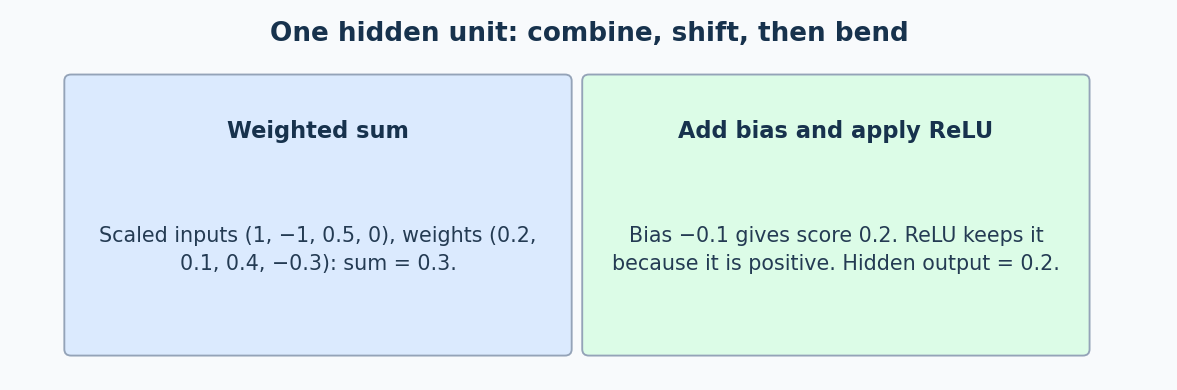

All eight hidden units perform this kind of calculation with their own parameters. The output layer then makes three new weighted sums from those hidden values.

These numbers explain the mechanism; they are not the learned parameters from the run. Training adjusts all sixty-seven parameters together according to how they affect the classification loss. A hidden unit need not acquire a simple label such as “petal detector” that we can read directly from its weights.

## Turn three scores into a choice and a loss

**Softmax** converts class logits into positive probabilities that sum to one. It exponentiates each score and divides by the sum of those exponentials. The largest logit also has the largest softmax probability.

For an illustrative output, imagine the probabilities are:

| Species | Estimated probability |
| --- | --- |
| Setosa | 0.1 |
| Versicolor | 0.7 |
| Virginica | 0.2 |

The model's chosen class is versicolor, the largest entry. But the training signal also needs to know the true label. **Cross-entropy** penalizes minus the natural logarithm of the probability assigned to that true class.

If the target is versicolor, the loss is $-\log(0.7)\approx0.357$. If the target is setosa, the same prediction gets $-\log(0.1)\approx2.303$. Assigning little probability to what actually happened is expensive.

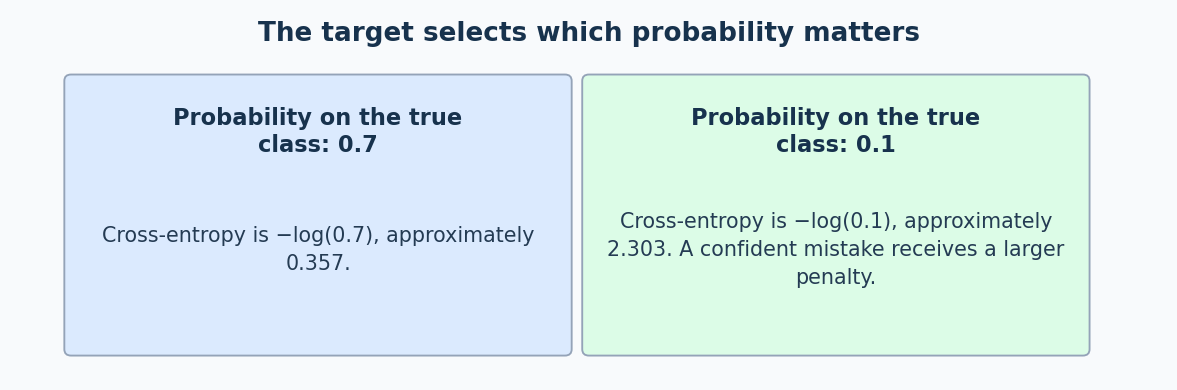

PyTorch's `CrossEntropyLoss` combines the stable log-probability calculation with this penalty, so pass it **raw logits**, not already-softmaxed probabilities. We apply softmax separately when displaying predictions.

For a batch of fifteen flowers, the logits have shape `(15, 3)`, and the targets have shape `(15,)`. Each target is an integer class index stored as `torch.long`. Fractional input measurements use floating-point storage instead.

## Give the project a simpler comparison model

A neural network should earn its extra complexity. We also fit **multinomial logistic regression** using the same scaled training features.

This baseline makes one linear score per class directly from the four inputs. It has no hidden layer. Its class probabilities still come from softmax, so it is a useful comparison for the same classification task.

| Property | Logistic-regression baseline | Small neural network |
| --- | --- | --- |
| Input features | Four scaled measurements | The same four scaled measurements |
| Hidden layer | None | Eight ReLU units |
| Stored coefficients and biases | Fifteen | Sixty-seven |
| Training examples | The same training group | The same training group |
| Complexity choice | Fixed regularization setting | Fixed architecture and update settings |

The baseline uses L2 regularization, a squared-weight penalty that discourages large coefficients. Its scikit-learn setting `C=1.0` is fixed for this demonstration; smaller values of this setting mean stronger regularization. We do not search settings after seeing test outcomes.

This comparison is informative without being an exhaustive optimizer or architecture competition. Equal access to data matters, but the methods have different fitting rules and modeling assumptions. A simpler model can be entirely adequate for this small task.

## Repeat the batch update, keeping each job clear

The training loader serves fifteen flowers at a time. A **batch** is that group; an **epoch** is one pass through all ninety training flowers. There are six batches per epoch.

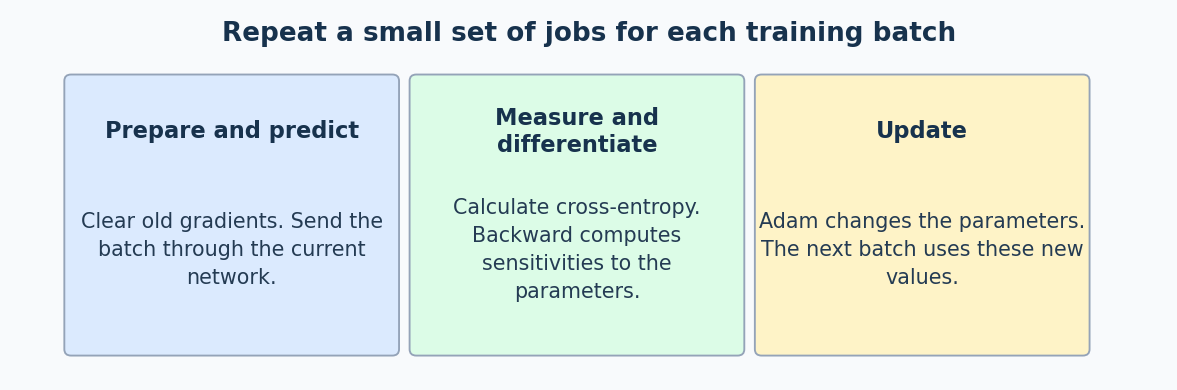

| Operation | What it does | Why it is needed |
| --- | --- | --- |
| Clear gradients | Remove stored contributions from the previous batch | PyTorch normally accumulates gradients |
| Forward pass | Compute current logits | Loss must describe the current parameters |
| Calculate loss | Compare logits with class targets | Specify the objective being improved |
| Backward pass | Find how loss responds to small parameter changes | Supply a gradient for each parameter |
| Optimizer step | Apply Adam's update rule | Actually change the parameter values |

**Backpropagation** is the backward calculation of those sensitivities. It does not itself change weights. **Adam** is an optimizer that uses running records of gradient directions and squared sizes to scale its changes. We create it once so that history persists.

The learning rate is $0.01$, and the budget is two hundred epochs: $200\times6=1200$ updates. These are demonstration settings, not values guaranteed to suit another task.

The data loader shuffles the training rows each epoch while preserving measurement-label pairs. This changes which examples arrive together without changing their group membership.

## Choose a saved state using validation evidence

After each epoch, pause updates and measure the complete training and validation groups using one fixed model state. A loss history collected this way avoids mixing together batch measurements taken at changing parameter values.

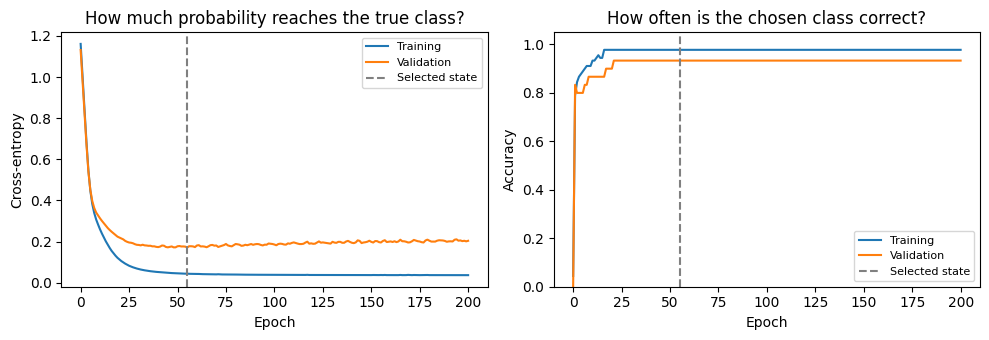

**Accuracy** counts the fraction of correct class choices. Cross-entropy also considers the probability on the true class, so the two curves need not move together. A correct prediction can become more confident without changing accuracy.

Whenever validation loss improves, the program takes a deep copy of the network's state. This **checkpoint** stays independent of later parameter changes. The initial, untrained state is also a candidate. At the end of the fixed budget, restore the state with the lowest validation loss.

| Call | Its role |
| --- | --- |
| `model.train()` | Select training behavior for layers that have mode-dependent behavior |
| `model.eval()` | Select evaluation behavior for those layers |
| `torch.no_grad()` | Stop recording operations for gradient calculations |

Our linear and ReLU layers behave the same in both modes, but stating the roles makes the boundary clear. Evaluation mode does not itself disable gradients.

The checkpoint need not come from the last epoch. Keeping a previous state is model selection, not early stopping: the notebook still completes the full budget. Test results do not enter this choice.

## Read the final comparison beyond a single percentage

After restoring the selected network, transform the test measurements with the stored training statistics and evaluate both fixed models. The code prints the number correct, accuracy, and log loss.

In the saved run, validation selected epoch $55$ after a total budget of $1200$ updates. The fixed models then produced:

| Model | Correct test flowers | Accuracy | Test log loss |
| --- | --- | --- | --- |
| Logistic regression | 28 out of 30 | About 93.3% | About 0.2067 |
| Small neural network | 28 out of 30 | About 93.3% | About 0.1403 |

Both made the same number of correct choices. The network had lower log loss on this group, but equal accuracy does not establish that the extra hidden layer is necessary. These numbers are specific to the saved run.

A **confusion matrix** shows which classes were mixed up. Actual species are rows; predicted species are columns. Diagonal entries are correct predictions, and off-diagonal entries are mistakes.

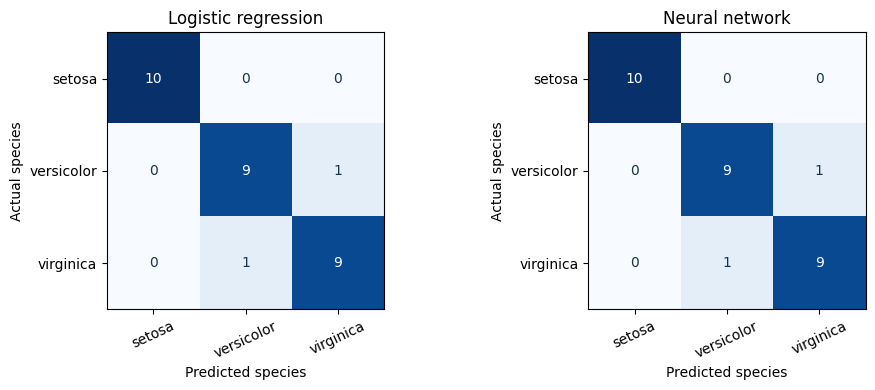

Each row contains ten test flowers. For example, an entry in the versicolor row and virginica column counts real versicolor flowers called virginica. Looking at those counts explains an accuracy score more clearly than the score alone.

There are only thirty test examples. One additional correct answer changes accuracy by $1/30\approx0.033$, or about three percentage points. A small difference on this split is not strong evidence of universal superiority.

Log loss is the average cross-entropy on these fixed predictions. It can distinguish models with the same accuracy because their confidence differs. Neither metric alone establishes that the probabilities are well calibrated: calibration means stated confidence agrees with observed frequencies across suitable groups of examples.

Inspecting these results ends the comparison. We do not choose new settings in response and then reuse the same test score as though it remained an untouched evaluation.

## Make another prediction without changing the recipe

A reusable predictor accepts raw measurements in centimeters, checks their arrangement, applies the stored scaling, and returns ordered class probabilities.

| Input requirement | Why it matters |
| --- | --- |
| A table with four columns | Each column must hold its expected measurement |
| The original feature order | Swapping petal width and sepal length changes the problem even if the shape is valid |
| Finite positive measurements | Missing, infinite, or nonpositive lengths are invalid for this interface |
| Shape `(1, 4)` for one flower | One row must remain a batch-shaped table |
| The saved training statistics | The network expects the same numerical representation used during fitting |

The companion demonstrates this interface on a training flower, so the example does not create another test-driven decision. It prints the chosen species and all three probabilities.

These numerical checks cannot verify that a measurement was taken correctly or that the flower belongs to a known species. A positive four-number row could still describe an unfamiliar plant or an input far from the training distribution.

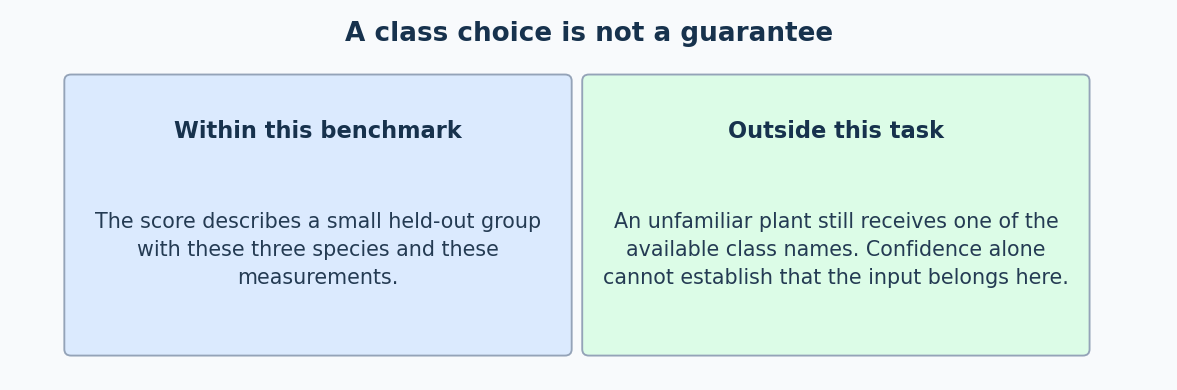

Confidence is a model output, not a certificate. A system intended for real use would need data from its actual setting and a way to handle inputs outside its intended scope.

## Save everything that gives the numbers their meaning

Saving the weights is only part of preserving the predictor. The same weights can give different answers if inputs are rearranged, scaled differently, or mapped to the wrong class names.

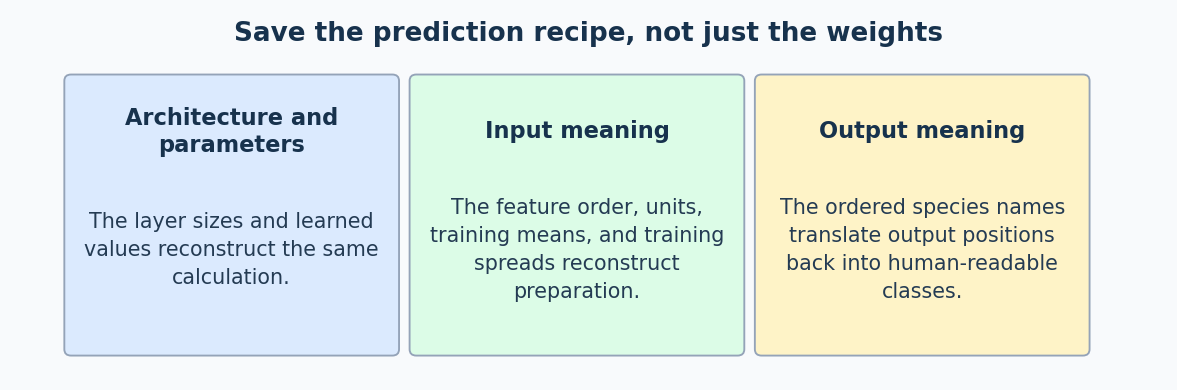

The companion stores a small bundle containing the model state, layer sizes, training means and standard deviations, ordered feature names, and ordered class names. The lesson specifies that the raw measurements are in centimeters.

It writes the bundle to a temporary file, reloads the trusted file it just created, reconstructs the architecture, and verifies that the same example produces matching probabilities. The temporary directory then removes that demonstration file, leaving the project notebooks tidy.

The bundle contains tensors and ordinary Python values. Class names are converted to ordinary Python strings so the restricted `weights_only=True` loader can restore the bundle without needing NumPy scalar objects.

This is a prediction snapshot, not everything needed to resume identical training. Continuing the same training process would also require optimizer history and other run state such as random-generator and data-order information.

The finished project connects data meaning, preparation, a learnable model, honest comparison, and a reusable prediction interface. Its small size lets us inspect that entire path, while its limitations remind us why a working notebook and a dependable real-world system are different achievements.

## Evaluate decisions, not only accuracy

For a binary classifier, a **confusion matrix** counts true positives, false positives, true negatives, and false negatives. Precision is $TP/(TP+FP)$: among predicted positives, how many were correct. Recall, or sensitivity, is $TP/(TP+FN)$: among actual positives, how many were found. $F1=2PR/(P+R)$ balances the two and is undefined when both are zero, so report the convention used.

A probability becomes a positive decision only after choosing a threshold. Lowering the threshold usually raises recall and lowers precision; raising it usually does the reverse. A precision-recall table at several thresholds makes that tradeoff explicit. The ROC curve plots true-positive rate against false-positive rate across thresholds. ROC-AUC is the probability that a randomly selected positive receives a higher score than a randomly selected negative; it summarizes ranking, not the operating threshold.

For multiclass results, **macro** averaging gives every class equal weight, **micro** pools all decisions before calculating a score, and **weighted** averages class scores weighted by support. Macro can reveal a neglected rare class; micro is dominated by common classes. State the averaging method.

## Prepare mixed input features without leaking information

Min-max scaling maps a feature using training-set bounds: $(x-min)/(max-min)$. It places values in a chosen interval such as $[0,1]$, but an unseen value can fall outside that interval. Fit the bounds on training data only. For a categorical input feature, one-hot encoding creates one indicator column per category, with one active entry per row. Fit the category vocabulary on training data and define a policy for unknown categories.